In [1]:
import pandas as pd

In [2]:
import sys, importlib
# sys.path.append('/mnt/data')
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utils loaded; available: 51


In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = '/projects/immunestatus/vdjdb'

In [6]:
info = pd.read_csv(f'{DATA_PATH}/tcrempnet_long_uni/trb_vdjdb_uni_summary_tcrempnet.tsv', sep='\t')

In [7]:
info

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change
0,0,3,3,0,0.000000,0.000000,10.919889
1,1,4,4,0,0.000000,0.000000,11.044828
2,2,3,3,0,0.000000,0.000000,10.919889
3,3,4,4,0,0.000000,0.000000,11.044828
4,4,12,11,1,0.000000,0.000000,2.484160
...,...,...,...,...,...,...,...
6975,6975,3,0,3,0.742167,0.742167,-8.034353
6976,6976,3,0,3,0.742167,0.742167,-8.034353
6977,6977,3,0,3,0.742167,0.742167,-8.034353
6978,6978,3,0,3,0.742167,0.742167,-8.034353


In [8]:
enriched = pd.read_csv(f'{DATA_PATH}/tcrempnet_long_uni/trb_vdjdb_uni_enriched_clonotypes_tcremp.tsv', sep='\t')
enriched

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom
0,s_0,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000
1,s_7,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000
2,s_17,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000
3,s_1,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.000000
4,s_8,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.000000
...,...,...,...,...,...,...,...
9049,b_284088,2135,CASSLVQNSYEQYF,TRBV5-1*01,TRBJ2-7*01,background,0.000552
9050,b_687854,2135,CASSLVENSYEQYF,TRBV5-1*01,TRBJ2-7*01,background,0.000552
9051,s_107671,2136,CASSLRTSGGTDTQYF,TRBV2*01,TRBJ2-3*01,sample,0.000000
9052,s_107678,2136,CASSVRTSGGTDTQYF,TRBV2*01,TRBJ2-3*01,sample,0.000000


In [9]:
vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')
vdjdb_init

/scratch/ipykernel_970029/928325651.py:1: DtypeWarning: Columns (5,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')


,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,mhc.b,...,meta.replica.id,meta.clone.id,meta.epitope.id,meta.tissue,meta.donor.MHC,meta.donor.MHC.method,meta.structure.id,cdr3fix.alpha,cdr3fix.beta,vdjdb.score
0,NaN,NaN,NaN,CASSIVGGNEQFF,TRBV19*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIVGGNEQFF', 'cdr3_old': 'CASSIVG...",3
1,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",3
2,NaN,NaN,NaN,CASSIRSAWAQYF,TRBV19*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSAWAQYF', 'cdr3_old': 'CASSIRS...",2
3,NaN,NaN,NaN,CASSQRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSQRSTGELFF', 'cdr3_old': 'CASSQRS...",2
4,NaN,NaN,NaN,CASSIRSSYEQYF,TRBV19*01,NaN,TRBJ2-7*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSSYEQYF', 'cdr3_old': 'CASSIRS...",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107954,NaN,NaN,NaN,CASSPSARGNQPQHF,TRBV2*01,TRBD1*01,TRBJ1-5*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB5*01:01,...,NaN,NaN,NaN,NaN,"DRB1*0102,DRB1*1101",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSPSARGNQPQHF', 'cdr3_old': 'CASSP...",0
107955,NaN,NaN,NaN,CASSVGTSGVGEQYF,TRBV2*01,TRBD2*01,TRBJ2-7*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB5*01:01,...,NaN,NaN,NaN,NaN,"DRB1*0102,DRB1*1101",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSVGTSGVGEQYF', 'cdr3_old': 'CASSV...",0
107956,NaN,NaN,NaN,CASSALASGGDTQYF,TRBV2*01,TRBD2*01,TRBJ2-3*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB1*15:02,...,NaN,NaN,NaN,NaN,"DRB1*0701/ 0703/0704/ 0705/ 0706,DRB1*1501/ 15...",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSALASGGDTQYF', 'cdr3_old': 'CASSA...",0
107957,NaN,NaN,NaN,CASSRLAGGMDEQFF,TRBV2*01,TRBD2*02,TRBJ2-1*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB1*15:02,...,NaN,NaN,NaN,NaN,"DRB1*0701/ 0703/0704/ 0705/ 0706,DRB1*1501/ 15...",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSRLAGGMDEQFF', 'cdr3_old': 'CASSR...",3


In [10]:
enriched = enriched[enriched.source == 'sample']

In [11]:
enriched['vdjdb_id'] = enriched.clone_id.apply(lambda x: int(x[2:]))

/scratch/ipykernel_970029/2839496545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enriched['vdjdb_id'] = enriched.clone_id.apply(lambda x: int(x[2:]))


In [12]:
enriched

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,vdjdb_id
0,s_0,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000,0
1,s_7,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000,7
2,s_17,0,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,sample,0.000000,17
3,s_1,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.000000,1
4,s_8,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.000000,8
...,...,...,...,...,...,...,...,...
9046,s_106926,2134,CASSQGGNEQFF,TRBV7-9*01,TRBJ2-1*01,sample,0.000000,106926
9048,s_106889,2135,CASSLVQNSYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,0.000552,106889
9051,s_107671,2136,CASSLRTSGGTDTQYF,TRBV2*01,TRBJ2-3*01,sample,0.000000,107671
9052,s_107678,2136,CASSVRTSGGTDTQYF,TRBV2*01,TRBJ2-3*01,sample,0.000000,107678


In [13]:
merged_data = vdjdb_init.reset_index().rename(columns={'index': 'vdjdb_id'}).merge(enriched)
merged_data.groupby('cluster_id').nunique()['antigen.epitope']

cluster_id
0       3
1       3
2       3
3       4
4       8
       ..
6509    1
6609    1
6785    1
6803    1
6835    1
Name: antigen.epitope, Length: 2103, dtype: int64

In [14]:
merged_data[merged_data.cluster_id == 1]#['antigen.epitope']

,vdjdb_id,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,...,cdr3fix.alpha,cdr3fix.beta,vdjdb.score,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom
1,1,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",3,s_1,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.0
8,8,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",2,s_8,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.0
19,20,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",2,s_20,1,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.0
30,67,NaN,NaN,NaN,CASSVRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASSVRSTGELFF', 'cdr3_old': 'CASSVRS...",3,s_67,1,CASSVRSTGELFF,TRBV19*01,TRBJ2-2*01,sample,0.0


In [15]:
motifs = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/cluster_members.txt', sep='\t')
motifs

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
0,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLSGDDYNEQFF,102.447143,32.107434,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
1,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDDYNEQFF,36.799698,2.795705,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
2,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDNYNEQFF,3.568838,-52.141266,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
3,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDSYNEQFF,-36.541775,-2.006452,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
4,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLVGDSYNEQFF,-105.450820,18.494963,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CAASENYNQGKLIF,308.410316,128.603566,M.A.TVYGFCLL.2,12,"TRAV7-4*01,TRAV7D-4*01",TRAJ23*01,5,5,TRAV12D-1*01,TRAJ23*01
35564,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIMNYNQGKLIF,187.064152,-192.603423,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35565,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIPNYNQGKLIF,267.595691,-180.697136,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35566,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALRENYNQGKLIF,242.143769,-43.271264,M.A.TVYGFCLL.2,12,TRAV12-3*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01


In [16]:
motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]

,cdr3aa,v.segm,j.segm,antigen.epitope
33739,CVVNMETDKLIF,TRAV12-1*01,TRAJ34*01,YLQPRTFLL
33740,CVVNMENDMRF,TRAV12-1*01,TRAJ43*01,YLQPRTFLL
33741,CASQDTNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
33742,CASQEANTGELFF,"TRBV19*01,TRBV4-3*01",TRBJ2-2*01,YLQPRTFLL
33743,CASQELDTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
...,...,...,...,...
34297,CATTDLNTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL
34298,CSARDALAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34299,CSARDDRALNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34300,CSARDDRAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL


In [18]:
vdjdb_tcrnet = motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]
vdjdb_tcrnet

,cdr3aa,v.segm,j.segm,antigen.epitope
33739,CVVNMETDKLIF,TRAV12-1*01,TRAJ34*01,YLQPRTFLL
33740,CVVNMENDMRF,TRAV12-1*01,TRAJ43*01,YLQPRTFLL
33741,CASQDTNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
33742,CASQEANTGELFF,"TRBV19*01,TRBV4-3*01",TRBJ2-2*01,YLQPRTFLL
33743,CASQELDTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
...,...,...,...,...
34297,CATTDLNTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL
34298,CSARDALAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34299,CSARDDRALNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34300,CSARDDRAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL


In [19]:
tcrvdb = pd.read_csv('../../data/01_05_2025_TCRvdb.csv').drop(columns=['Unnamed: 0']).dropna(subset=['padj'])
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'padj']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,padj
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,1.636410e-40
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,5.774793e-03
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,1.000000e+00
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,1.296120e-01
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,6.701844e-56
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,4.228298e-01
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,1.481753e-86
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,5.187643e-01
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,1.000000e+00


In [20]:
tcrvdb['valid'] = tcrvdb.padj < 10**-5 

In [21]:
tcrvdb[tcrvdb.epitope_aa.str.startswith('YLQ')]

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,hla_long,data_origin,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,valid
0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40,True
1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,TRAV5*01,...,A*02:01,vdjdb,1.0,48.227439,-1.112206,0.302166,-3.349832,8.086058e-04,5.774793e-03,False
2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,TRAV35*01,...,A*02:01,vdjdb,0.0,77.593373,0.206727,0.238408,0.447668,6.543928e-01,1.000000e+00,False
3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,TRAV21*01,...,A*02:01,vdjdb,0.0,21.861277,1.116579,0.451138,2.253366,2.423609e-02,1.296120e-01,False
4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,1_6_C19_126_YLQPRTFLL,TRAV19_CALSEASTGNQFYF_TRAJ49--TRBV20-1_CSASRGG...,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,TRAV19*01,...,A*02:01,vdjdb,0.0,28.712481,0.088951,0.364827,0.000000,1.000000e+00,1.000000e+00,False
436,1_6_C20_127_YLQPRTFLL,TRAV12-1_CVVNNNNDMRF_TRAJ43--TRBV12-3_CARGDANT...,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,184.810662,-2.425191,0.190807,-12.186085,3.687152e-34,7.181566e-33,True
437,1_6_C18_125_YLQPRTFLL,TRAV35_CAGQRGGADGLTF_TRAJ45--TRBV13_CASSLAAAYE...,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,TRAV35*01,...,A*02:01,vdjdb,0.0,40.502523,-0.369620,0.318511,-0.846502,3.972728e-01,9.392174e-01,False
438,1_6_C3_26_YLQPRTFLL,TRAV4_CLVGENFNKFYF_TRAJ21--TRBV5-1_CASSLGQSLEQ...,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,TRAV4*01,...,A*02:01,vdjdb,0.0,363.670607,-0.153974,0.137708,-0.391947,6.950970e-01,1.000000e+00,False


In [22]:
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'valid']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,valid
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,False
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,False
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,False
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,False
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,True
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,False
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,False


In [23]:
vdjdb_clust = merged_data[
    merged_data['antigen.epitope'].str.startswith('YLQ')][
    ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']]
vdjdb_clust

,vdjdb_id,cdr3aa_beta,v_beta,j_beta,antigen.epitope
150,6166,CARQDSNTGELFF,TRBV12-3*01,TRBJ2-2*01,YLQPRTFLL
151,6179,CAIQEANTGELFF,TRBV19*01,TRBJ2-2*01,YLQPRTFLL
154,6287,CASQDSNTGELFF,TRBV5-1*01,TRBJ2-2*01,YLQPRTFLL
156,6434,CASEDLNTGELFF,TRBV6-5*01,TRBJ2-2*01,YLQPRTFLL
158,6468,CASSPDIEAFF,TRBV7-9*01,TRBJ1-1*01,YLQPRTFLL
346,22051,CASSLDIEQYF,TRBV7-9*01,TRBJ2-7*01,YLQPRTFLL
610,35280,CASSPGDTQYF,TRBV25-1*01,TRBJ2-3*01,YLQPRTFLL
611,35400,CASSEGDEQYF,TRBV2*01,TRBJ2-7*01,YLQPRTFLL
614,36193,CAPGSANTGELFF,TRBV7-9*01,TRBJ2-2*01,YLQPRTFLL
7325,88207,CASQEANTGELFF,TRBV19*01,TRBJ2-2*01,YLQPRTFLL


In [24]:
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'valid']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,valid
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,False
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,False
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,False
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,False
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,True
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,False
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,False


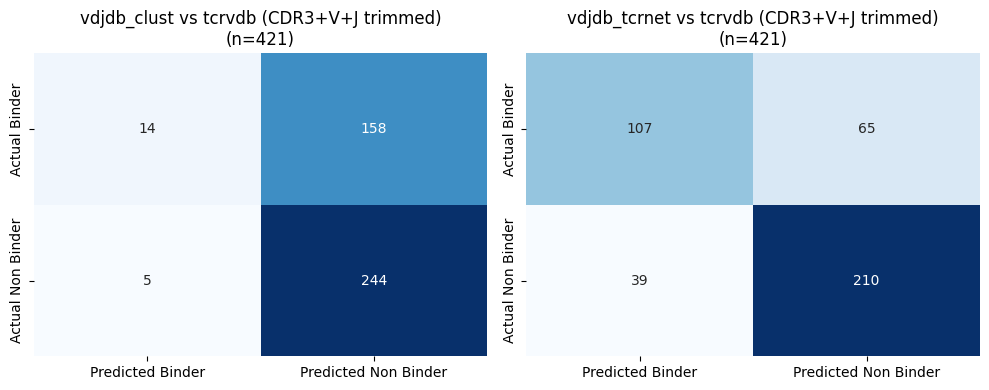

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def trim_allele(gene):
    """Удаляет часть после звёздочки: TRBV28*01 -> TRBV28"""
    if pd.isna(gene):
        return gene
    return re.sub(r'\*.*$', '', gene)

def confusion_summary_vj_trimmed(tcrvdb, other_df, cols_other):
    """
    Строит TP/FP/FN/TN для таблицы tcrvdb против другой таблицы,
    учитывая совпадение по CDR3 + V + J (с обрезкой аллелей)
    cols_other — словарь с ключами 'cdr3', 'v', 'j'
    """
    df = tcrvdb.copy()
    df['V_trim'] = df['TRBV'].apply(trim_allele)
    df['J_trim'] = df['TRBJ'].apply(trim_allele)
    df['key'] = df['cdr3_beta_aa'] + '|' + df['V_trim'] + '|' + df['J_trim']

    other_df = other_df.copy()
    other_df['V_trim'] = other_df[cols_other['v']].apply(trim_allele)
    other_df['J_trim'] = other_df[cols_other['j']].apply(trim_allele)
    other_df['key'] = (
        other_df[cols_other['cdr3']] + '|' +
        other_df['V_trim'] + '|' +
        other_df['J_trim']
    )

    df['in_other'] = df['key'].isin(other_df['key'])

    df['category'] = df.apply(
        lambda r: 'TP' if r['in_other'] and r['valid']
        else 'FP' if r['in_other'] and not r['valid']
        else 'FN' if not r['in_other'] and r['valid']
        else 'TN',
        axis=1
    )
    return df['category'].value_counts().reindex(['TP', 'FP', 'FN', 'TN'], fill_value=0)

vdjdb_clust = merged_data[
    merged_data['antigen.epitope'].str.startswith('YLQ')][
    ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']]

# === 1. для vdjdb_clust ===
summary_clust = confusion_summary_vj_trimmed(
    tcrvdb[tcrvdb['epitope_aa'].str.startswith('YLQ')], 
    vdjdb_clust, 
    cols_other={'cdr3': 'cdr3aa_beta', 'v': 'v_beta', 'j': 'j_beta'}
)

# === 2. для vdjdb_tcrnet ===

vdjdb_tcrnet = motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]

summary_tcrnet = confusion_summary_vj_trimmed(
    tcrvdb[tcrvdb['epitope_aa'].str.startswith('YLQ')],
    vdjdb_tcrnet,
    cols_other={'cdr3': 'cdr3aa', 'v': 'v.segm', 'j': 'j.segm'}
)

# === 3. рисуем две heatmap рядом ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def draw_heatmap(summary, ax, title):
    total = summary.sum()
    data = [[summary['TP'], summary['FN']],
            [summary['FP'], summary['TN']]]
    sns.heatmap(data, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Binder', 'Predicted Non Binder'],
                yticklabels=['Actual Binder', 'Actual Non Binder'], ax=ax)
    ax.set_title(title + f"\n(n={total})")

draw_heatmap(summary_clust, axes[0], "vdjdb_clust vs tcrvdb (CDR3+V+J trimmed)")
draw_heatmap(summary_tcrnet, axes[1], "vdjdb_tcrnet vs tcrvdb (CDR3+V+J trimmed)")

plt.tight_layout()
plt.show()



=== YLQ ===

=== GLC ===


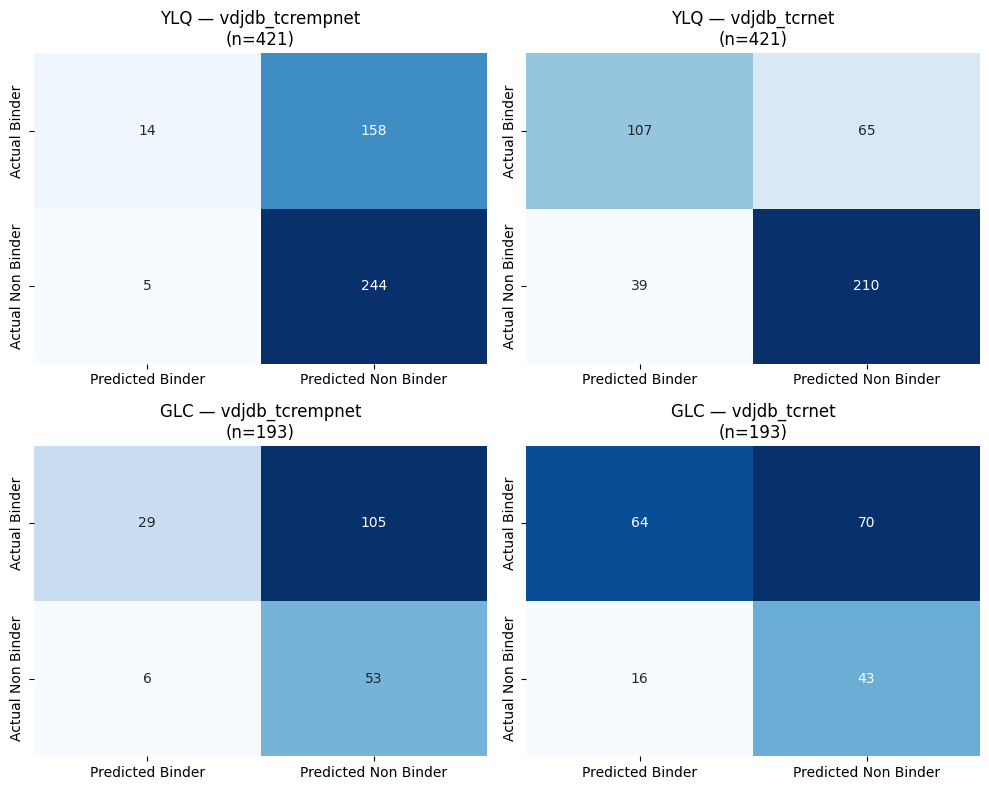


YLQ metrics:
vdjdb_clust:
 precision    0.736842
recall       0.081395
f1           0.146597
dtype: float64
vdjdb_tcrnet:
 precision    0.732877
recall       0.622093
f1           0.672956
dtype: float64

GLC metrics:
vdjdb_clust:
 precision    0.828571
recall       0.216418
f1           0.343195
dtype: float64
vdjdb_tcrnet:
 precision    0.800000
recall       0.477612
f1           0.598131
dtype: float64


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def trim_allele(gene):
    """Удаляет часть после звёздочки: TRBV28*01 -> TRBV28"""
    if pd.isna(gene):
        return gene
    return re.sub(r'\*.*$', '', gene)

def confusion_summary_vj_trimmed(tcrvdb, other_df, cols_other):
    """
    Строит TP/FP/FN/TN и метрики precision, recall, F1
    с учётом совпадения по CDR3 + V + J (обрезая аллели)
    """
    df = tcrvdb.copy()
    df['V_trim'] = df['TRBV'].apply(trim_allele)
    df['J_trim'] = df['TRBJ'].apply(trim_allele)
    df['key'] = df['cdr3_beta_aa'] + '|' + df['V_trim'] + '|' + df['J_trim']

    other_df = other_df.copy()
    other_df['V_trim'] = other_df[cols_other['v']].apply(trim_allele)
    other_df['J_trim'] = other_df[cols_other['j']].apply(trim_allele)
    other_df['key'] = (
        other_df[cols_other['cdr3']] + '|' +
        other_df['V_trim'] + '|' +
        other_df['J_trim']
    )

    df['in_other'] = df['key'].isin(other_df['key'])

    df['category'] = df.apply(
        lambda r: 'TP' if r['in_other'] and r['valid']
        else 'FP' if r['in_other'] and not r['valid']
        else 'FN' if not r['in_other'] and r['valid']
        else 'TN',
        axis=1
    )

    summary = df['category'].value_counts().reindex(['TP', 'FP', 'FN', 'TN'], fill_value=0)

    # Метрики
    TP, FP, FN, TN = summary['TP'], summary['FP'], summary['FN'], summary['TN']
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    metrics = pd.Series({
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    return summary, metrics


def draw_heatmap(summary, ax, title):
    total = summary.sum()
    data = [[summary['TP'], summary['FN']],
            [summary['FP'], summary['TN']]]
    sns.heatmap(data, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Binder', 'Predicted Non Binder'],
                yticklabels=['Actual Binder', 'Actual Non Binder'], ax=ax)
    ax.set_title(title + f"\n(n={total})")


# === Анализ для двух эпитопов ===
epitopes = ['YLQ', 'GLC']
results = {}

for epi in epitopes:
    print(f"\n=== {epi} ===")

    # Фильтруем данные
    tcrvdb_epi = tcrvdb[tcrvdb['epitope_aa'].str.startswith(epi)]
    vdjdb_clust_epi = merged_data[merged_data['antigen.epitope'].str.startswith(epi)][
        ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']
    ]
    vdjdb_tcrnet_epi = motifs[motifs['antigen.epitope'].str.startswith(epi)][
        ['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']
    ]

    # Вычисляем confusion matrix и метрики
    summary_clust, metrics_clust = confusion_summary_vj_trimmed(
        tcrvdb_epi, vdjdb_clust_epi,
        cols_other={'cdr3': 'cdr3aa_beta', 'v': 'v_beta', 'j': 'j_beta'}
    )
    summary_tcrnet, metrics_tcrnet = confusion_summary_vj_trimmed(
        tcrvdb_epi, vdjdb_tcrnet_epi,
        cols_other={'cdr3': 'cdr3aa', 'v': 'v.segm', 'j': 'j.segm'}
    )

    # Сохраняем результаты
    results[epi] = {
        'clust': (summary_clust, metrics_clust),
        'tcrnet': (summary_tcrnet, metrics_tcrnet)
    }

# === Визуализация ===
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, epi in enumerate(epitopes):
    summary_clust, _ = results[epi]['clust']
    summary_tcrnet, _ = results[epi]['tcrnet']

    draw_heatmap(summary_clust, axes[i, 0], f"{epi} — vdjdb_tcrempnet")
    draw_heatmap(summary_tcrnet, axes[i, 1], f"{epi} — vdjdb_tcrnet")

plt.tight_layout()
plt.show()

# === Печать метрик ===
for epi in epitopes:
    print(f"\n{epi} metrics:")
    print("vdjdb_clust:\n", results[epi]['clust'][1])
    print("vdjdb_tcrnet:\n", results[epi]['tcrnet'][1])
